# 01 · Análise exploratória

**Projeto:** Cronos · Challenge FIAP 2026 com Locaweb
**Autores:** Ana Beatriz Costa de Oliveira · Hygor Abrantes · Igor Vignola
**Criado em:** 21/05/2026 · **Atualizado em:** 17/08/2026

Caracterização do LWDATASET: período coberto, distribuição do volume, sazonalidade diária,
concentração por produto e por equipe, e frequência de violação de OLA. Os resultados definem o
recorte de dados e as variáveis de calendário usadas na modelagem.

**Entrada:** `assets/Materal LocalWeb/LW-DATASET.xlsx`, aba `Dataset Geral`.
**Saída:** figuras em `notebooks/figures/01_eda/`.
**Bibliotecas:** pandas, numpy, matplotlib, plotly, holidays, openpyxl (Python 3.11+).

In [1]:
%matplotlib inline

# Stdlib
import warnings
from pathlib import Path

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.io as pio
import plotly.graph_objects as go
import holidays

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Setup

Caminhos do projeto, estilo visual das figuras e funções auxiliares de plotagem.

In [2]:
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PATH = REPO_ROOT / 'assets' / 'Materal LocalWeb' / 'LW-DATASET.xlsx'
FIGURES_DIR = NOTEBOOK_DIR / 'figures' / '01_eda'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT  : {REPO_ROOT}')
print(f'DATA_PATH  : {DATA_PATH}  (existe: {DATA_PATH.exists()})')
print(f'FIGURES_DIR: {FIGURES_DIR}')

REPO_ROOT  : C:\Users\igor.vignola\Documents\Personal\FIAP\Challenge-LocaWeb
DATA_PATH  : C:\Users\igor.vignola\Documents\Personal\FIAP\Challenge-LocaWeb\assets\Materal LocalWeb\LW-DATASET.xlsx  (existe: True)
FIGURES_DIR: C:\Users\igor.vignola\Documents\Personal\FIAP\Challenge-LocaWeb\notebooks\figures\01_eda


In [3]:
CRONOS_COLORS = {
    'black':      '#000000',
    'dark_gray':  '#444444',
    'mid_gray':   '#888888',
    'light_gray': '#F7F7F7',
    'white':      '#FFFFFF',
    'accent':     '#2563EB',  # azul Cronos, cor de destaque
    'danger':     '#DC2626',  # vermelho, perigo/critico
    'success':    '#16A34A',
    'warning':    '#D97706',
}


def setup_cronos_style():
    """Aplica o estilo visual do Cronos ao Matplotlib."""
    mpl.rcParams.update({
        'figure.figsize': (10, 5),
        'figure.dpi': 100,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': '#444444',
        'axes.linewidth': 0.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.titlesize': 16,
        'axes.titleweight': 'bold',
        'axes.titlelocation': 'left',
        'axes.titlepad': 16,
        'axes.labelsize': 12,
        'axes.labelcolor': '#444444',
        'axes.grid': True,
        'axes.axisbelow': True,
        'grid.color': '#E5E5E5',
        'grid.linewidth': 0.5,
        'xtick.color': '#888888',
        'ytick.color': '#888888',
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Sora', 'Segoe UI', 'DejaVu Sans'],
        'font.size': 11,
        'legend.frameon': False,
        'legend.fontsize': 11,
    })
    plt.rcParams['axes.grid.axis'] = 'y'


setup_cronos_style()

CRONOS_TEMPLATE = go.layout.Template(
    layout=dict(
        font=dict(family='Sora, Segoe UI, sans-serif', size=12, color='#444444'),
        title=dict(font=dict(size=18, color='#000000'), x=0.02, xanchor='left'),
        paper_bgcolor='white',
        plot_bgcolor='white',
        xaxis=dict(
            showgrid=False,
            linecolor='#444444',
            tickcolor='#888888',
            tickfont=dict(size=11, color='#888888'),
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor='#E5E5E5',
            gridwidth=0.5,
            linecolor='#444444',
            tickcolor='#888888',
            tickfont=dict(size=11, color='#888888'),
        ),
        colorway=['#2563EB', '#000000', '#888888', '#DC2626', '#16A34A', '#D97706'],
    )
)
pio.templates['cronos'] = CRONOS_TEMPLATE
pio.templates.default = 'cronos'

print('Estilo Cronos aplicado (Matplotlib + Plotly).')

Estilo Cronos aplicado (Matplotlib + Plotly).


In [4]:
def titulo_cronos(ax, main, sub):
    """Título à esquerda + subtítulo factual de uma linha."""
    ax.set_title(main, loc='left', pad=34, fontsize=15, fontweight='bold', color='#000000')
    ax.text(0, 1.04, sub, transform=ax.transAxes, fontsize=10.5, color='#5f5f5f', va='bottom')


def hbar_cronos(ax, serie, destaque=None):
    """Barra horizontal ordenada (maior no topo), rótulos ao lado. Destaque opcional em azul."""
    s = serie.sort_values()
    cores = [CRONOS_COLORS['accent'] if (destaque is not None and k == destaque)
             else CRONOS_COLORS['dark_gray'] for k in s.index]
    ax.barh(range(len(s)), s.values, color=cores)
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels(s.index)
    ax.grid(axis='x')
    ax.grid(axis='y', visible=False)
    for i, v in enumerate(s.values):
        ax.text(v, i, f' {int(v):,}'.replace(',', '.'), va='center', fontsize=9, color='#444444')


MESES_PT = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun', 'jul', 'ago', 'set', 'out', 'nov', 'dez']


def rotulo_mes(ym):
    """Converte 'YYYY-MM' em 'mmm/AAAA' (ex.: '2025-01' -> 'jan/2025')."""
    ano, mes = ym.split('-')
    return f'{MESES_PT[int(mes) - 1]}/{ano}'

## 2. Carga e visão geral

Leitura da aba `Dataset Geral` e verificação de estrutura, tipos, estatísticas descritivas e
completude dos campos.

In [5]:
df = pd.read_excel(DATA_PATH, sheet_name='Dataset Geral')

print(f'Linhas: {len(df):,} | Colunas: {df.shape[1]}')
print(f'Período: {df["Aberto"].min():%d/%m/%Y} a {df["Aberto"].max():%d/%m/%Y}')

Linhas: 122,543 | Colunas: 19
Período: 02/01/2023 a 31/12/2025


In [6]:
df.head()

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18,NaT,2025-12-31 23:45:32,14,NaN,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36,NaT,2025-12-31 23:43:05,209,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10,NaT,2025-12-31 23:25:00,110,NaN,Problem: Alarm Application Monitoring database...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
3,INC8654263,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:07,NaT,2025-12-31 23:24:57,110,NaN,Problem: Alarm Application Monitoring coupons ...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
4,INC8654262,4 - Baixa,NaN,NaN,NaN,Team14,IC00003,2025-12-31 23:23:05,NaT,2025-12-31 23:23:47,42,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Número                122543 non-null  object        
 1   Prioridade            122543 non-null  object        
 2   Produto               44608 non-null   object        
 3   Categoria             44822 non-null   object        
 4   Subcategoria          44823 non-null   object        
 5   Grupo designado       122543 non-null  object        
 6   Item de configuração  120763 non-null  object        
 7   Aberto                122543 non-null  datetime64[ns]
 8   Resolvido             40241 non-null   datetime64[ns]
 9   Encerrado             122543 non-null  datetime64[ns]
 10  Duração               122543 non-null  int64         
 11  Código de fechamento  40804 non-null   object        
 12  Descrição resumida    122543 non-null  object        
 13 

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Número,122543,122543,INC7227672,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Prioridade,122543,5,4 - Baixa,64828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Produto,44608,51,lhco,12835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Categoria,44822,141,cat71,7335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subcategoria,44823,447,sub7,4668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grupo designado,122543,17,Team14,92775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item de configuração,120763,9171,IC00014,6069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aberto,122543,NaN,NaN,NaN,2025-09-18 22:10:35.012746752,2023-01-02 20:19:58,2025-09-02 10:30:35,2025-10-14 00:11:49,2025-11-26 18:11:42.500000,2025-12-31 23:45:18,NaN
Resolvido,40241,NaN,NaN,NaN,2025-06-30 07:35:15.915683328,2024-12-27 00:50:52,2025-03-26 08:17:00,2025-07-01 13:51:22,2025-10-01 16:07:13,2025-12-31 19:36:58,NaN
Encerrado,122543,NaN,NaN,NaN,2025-09-22 18:42:48.700783104,2025-01-01 00:10:45,2025-09-03 18:35:03.500000,2025-10-15 23:55:36,2025-11-28 01:53:03,2025-12-31 23:45:32,NaN


In [9]:
faltantes = pd.DataFrame({
    'nulos': df.isna().sum(),
    '% nulo': (df.isna().mean() * 100).round(1),
}).sort_values('nulos', ascending=False)
faltantes

,nulos,% nulo
Incidente Pai,107416,87.7
Solução,107243,87.5
KPI Violado?,96943,79.1
Resolvido,82302,67.2
Código de fechamento,81739,66.7
Produto,77935,63.6
Categoria,77721,63.4
Subcategoria,77720,63.4
Item de configuração,1780,1.5
Prioridade,0,0.0


In [10]:
# 'KPI Violado?' parece só existir quando o incidente entra no KPI. Confere se a regra é exata.
pd.crosstab(df['Entrou para KPI?'], df['KPI Violado?'].fillna('(nulo)'))

KPI Violado?,(nulo),NAO,SIM
Entrou para KPI?,,,
NAO,96943,0,0
SIM,0,25352,248


In [11]:
# 'Duração' é inteiro e o dicionário não declara a unidade. Confere contra os marcos temporais.
com_resolvido = df['Resolvido'].notna()
seg_resolucao = (df['Resolvido'] - df['Aberto']).dt.total_seconds()
seg_encerramento = (df['Encerrado'] - df['Aberto']).dt.total_seconds()

n_res = int((df.loc[com_resolvido, 'Duração'] == seg_resolucao[com_resolvido]).sum())
n_enc = int((df.loc[~com_resolvido, 'Duração'] == seg_encerramento[~com_resolvido]).sum())
print(f'Duração == (Resolvido - Aberto) em segundos: {n_res:,} de {int(com_resolvido.sum()):,}')
print(f'Duração == (Encerrado - Aberto) em segundos: {n_enc:,} de {int((~com_resolvido).sum()):,}')

print('\nmediana de Duração em minutos, por status:')
print((df.groupby('Status')['Duração'].median() / 60).round(1).to_string())

Duração == (Resolvido - Aberto) em segundos: 40,241 de 40,241
Duração == (Encerrado - Aberto) em segundos: 81,805 de 82,302

mediana de Duração em minutos, por status:
Status
Aguardando Problema          242.3
Encerrado                     52.4
Encerrado Automaticamente    131.2
Sem Intervenção                5.6


122.543 registros em 19 colunas, abertos entre 02/01/2023 e 31/12/2025. Os marcos temporais
(`Aberto`, `Resolvido`, `Encerrado`) chegam tipados como `datetime64` e os demais campos são
categóricos em texto, com exceção de `Duração`.

A completude separa os campos em dois grupos. `Prioridade`, `Grupo designado`, `Aberto por`,
`Status` e `Entrou para KPI?` estão preenchidos em 100% dos registros. `Produto` (36,4%),
`Categoria` (36,6%), `Subcategoria` (36,6%), `Resolvido` (32,8%) e `Código de fechamento`
(33,3%) cobrem cerca de um terço da base.

`KPI Violado?` é nulo em 96.943 registros. O cruzamento com `Entrou para KPI?` mostra
correspondência exata: o campo é nulo em todas as linhas com `NAO` e preenchido em todas as
linhas com `SIM`. **A avaliação de OLA existe apenas no recorte elegível, com 25.600 registros.**

`Duração` é inteiro em segundos, e a janela que ele mede depende do incidente: nos 40.241
registros com `Resolvido` equivale a `Resolvido - Aberto`, e nos demais equivale a
`Encerrado - Aberto` em 99,4% dos casos. A distinção importa porque o índice de saúde por
produto usa esse campo como tempo de resolução.

## 3. Preparo

Colunas derivadas de calendário (`mes`, `data`), indicador de preenchimento de produto e recorte
dos incidentes elegíveis ao KPI.

In [12]:
df['mes'] = df['Aberto'].dt.to_period('M').astype(str)
df['data'] = df['Aberto'].dt.normalize()
df['tem_produto'] = df['Produto'].notna()

# 'Entrou para KPI?' é o campo oficial da Locaweb e já combina as três regras de elegibilidade:
# prioridade 1/2/3, sem incidente pai e status diferente de "Sem Intervenção". Filtrar só por
# 'Incidente Pai' vazio devolveria 107 mil linhas, que é o recorte errado.
df_kpi = df[df['Entrou para KPI?'] == 'SIM'].copy()

MESES_2025 = [f'2025-{k:02d}' for k in range(1, 13)]

print(f'base completa   : {len(df):,}')
print(f'elegível ao KPI : {len(df_kpi):,} ({len(df_kpi) / len(df) * 100:.0f}% da base)')

base completa   : 122,543
elegível ao KPI : 25,600 (21% da base)


## 4. Análise

### 4.1 Distribuição do volume no período

Contagem de incidentes por mês de abertura, sobre a base completa.

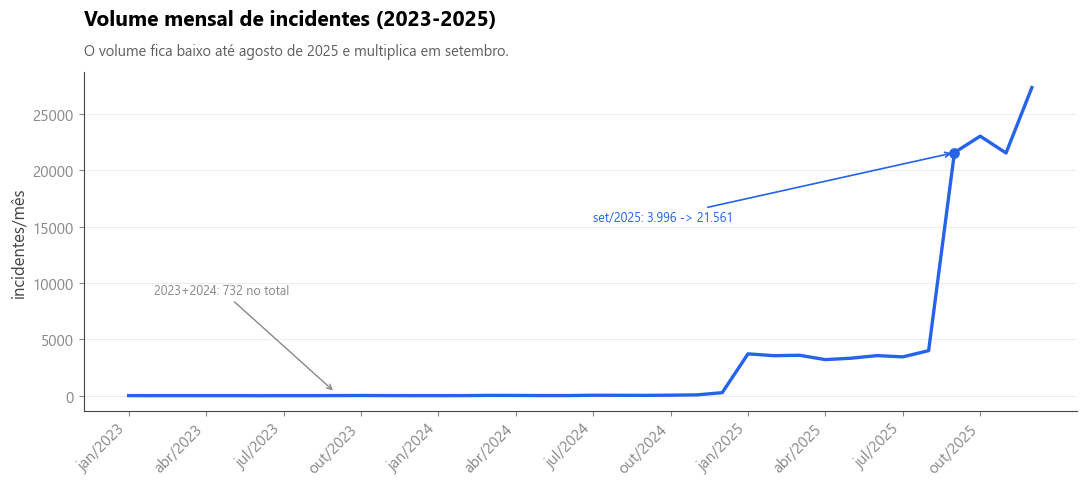

2023+2024: 732 incidentes de 122,543
ago/2025: 3,996 | set/2025: 21,561 (5.4x)


In [13]:
vol_mensal = df.groupby('mes').size()
n_23_24 = int((df['Aberto'].dt.year < 2025).sum())
i_set = list(vol_mensal.index).index('2025-09')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(len(vol_mensal)), vol_mensal.values, color=CRONOS_COLORS['accent'], lw=2.4)
ax.scatter([i_set], [vol_mensal.iloc[i_set]], color=CRONOS_COLORS['accent'], s=45, zorder=3)
titulo_cronos(ax, 'Volume mensal de incidentes (2023-2025)',
              'O volume fica baixo até agosto de 2025 e multiplica em setembro.')
ax.set_ylabel('incidentes/mês')
ax.set_xticks(range(0, len(vol_mensal), 3))
ax.set_xticklabels([rotulo_mes(m) for m in vol_mensal.index[::3]], rotation=45, ha='right')
ax.annotate(f"set/2025: {vol_mensal['2025-08']:,} -> {vol_mensal['2025-09']:,}".replace(',', '.'),
            xy=(i_set, vol_mensal.iloc[i_set]),
            xytext=(i_set - 14, vol_mensal.iloc[i_set] * 0.72), fontsize=9,
            color=CRONOS_COLORS['accent'],
            arrowprops=dict(arrowstyle='->', color=CRONOS_COLORS['accent'], lw=1.2))
ax.annotate(f'2023+2024: {n_23_24} no total', xy=(8, 300), xytext=(1, 9000), fontsize=9,
            color=CRONOS_COLORS['mid_gray'],
            arrowprops=dict(arrowstyle='->', color=CRONOS_COLORS['mid_gray'], lw=1))
fig.tight_layout()
fig.savefig(FIGURES_DIR / '41_volume_mensal.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f'2023+2024: {n_23_24} incidentes de {len(df):,}')
print(f"ago/2025: {vol_mensal['2025-08']:,} | set/2025: {vol_mensal['2025-09']:,} "
      f"({vol_mensal['2025-09'] / vol_mensal['2025-08']:.1f}x)")

2023 e 2024 somam 732 incidentes. Em 2025 o volume mensal fica na casa dos milhares e, entre
agosto e setembro, passa de 3.996 para 21.561, fator de 5,4, mantendo esse patamar até dezembro.

A magnitude e a velocidade da variação são incompatíveis com oscilação de carga operacional e
**indicam alteração no critério de registro**.

### 4.2 Mudança de patamar em setembro de 2025

Ponto de investigação sinalizado pela Locaweb. Decomposição do volume mensal de 2025 pelo campo
`Aberto por`, que distingue abertura manual de abertura por monitoramento.

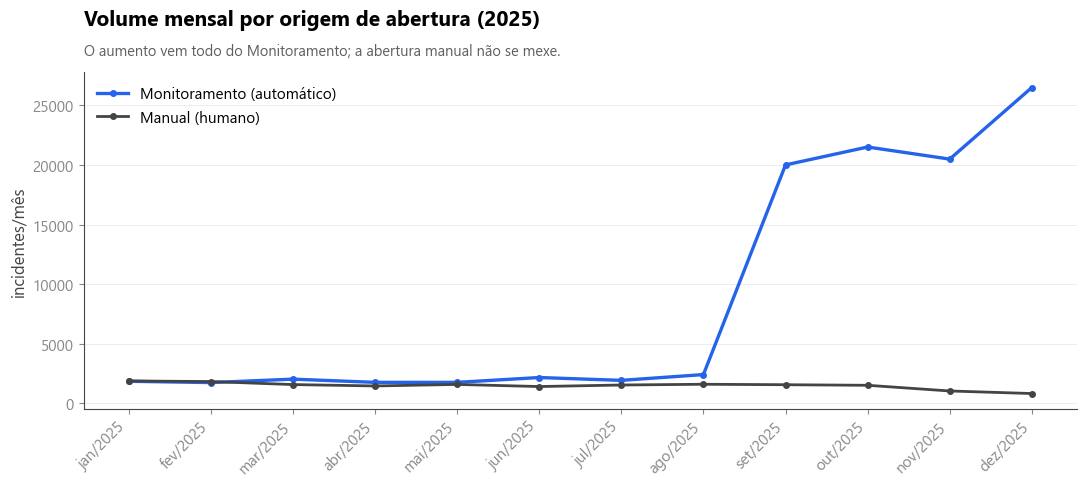

Monitoramento -> ago: 2404 | set: 20008
Manual        -> ago: 1592 | set: 1553
Manual em 2025: mín 814 | máx 1870


In [14]:
df_2025 = df[df['mes'].isin(MESES_2025)]
por_origem = df_2025.pivot_table(index='mes', columns='Aberto por', values='Número',
                                 aggfunc='count', fill_value=0).reindex(MESES_2025, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(por_origem))
ax.plot(x, por_origem['Monitoramento'], color=CRONOS_COLORS['accent'], lw=2.4, marker='o', ms=4,
        label='Monitoramento (automático)')
ax.plot(x, por_origem['Manual'], color=CRONOS_COLORS['dark_gray'], lw=2.0, marker='o', ms=4,
        label='Manual (humano)')
titulo_cronos(ax, 'Volume mensal por origem de abertura (2025)',
              'O aumento vem todo do Monitoramento; a abertura manual não se mexe.')
ax.set_ylabel('incidentes/mês')
ax.set_xticks(list(x))
ax.set_xticklabels([rotulo_mes(m) for m in por_origem.index], rotation=45, ha='right')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '42a_origem.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print('Monitoramento -> ago:', int(por_origem.loc['2025-08', 'Monitoramento']),
      '| set:', int(por_origem.loc['2025-09', 'Monitoramento']))
print('Manual        -> ago:', int(por_origem.loc['2025-08', 'Manual']),
      '| set:', int(por_origem.loc['2025-09', 'Manual']))
print('Manual em 2025: mín', int(por_origem['Manual'].min()), '| máx', int(por_origem['Manual'].max()))

O aumento vem inteiramente da origem Monitoramento, que passa de 2.404 para 20.008 entre agosto
e setembro. A abertura manual oscila entre 814 e 1.870 por mês em 2025 e não acompanha o
movimento: 1.592 em agosto contra 1.553 em setembro.

**Hipótese:** expansão da cobertura de monitoramento. Se for o caso, três indicadores devem se
deslocar no mesmo mês: incidentes autorresolvidos, ativos sem registro anterior e descrições de
checagem automática.

In [15]:
sem_intervencao = (df[(df['Status'] == 'Sem Intervenção') & df['mes'].isin(MESES_2025)]
                   .groupby('mes').size().reindex(MESES_2025, fill_value=0))
print('Incidentes com status "Sem Intervenção" por mês (2025):')
print(sem_intervencao.to_string())

# Data de abertura mais antiga de cada ativo = mês em que ele entrou na base.
primeira_aparicao = (df.dropna(subset=['Item de configuração'])
                     .groupby('Item de configuração')['Aberto'].min()
                     .dt.to_period('M').astype(str))
ics_novos = primeira_aparicao.value_counts().sort_index().reindex(MESES_2025, fill_value=0)
print('\nItens de configuração vistos pela primeira vez no mês (2025):')
print(ics_novos.to_string())

print('\nTop 5 descrições de setembro/2025:')
print(df.loc[df['mes'] == '2025-09', 'Descrição resumida'].value_counts().head(5).to_string())

Incidentes com status "Sem Intervenção" por mês (2025):
mes
2025-01        1
2025-02        7
2025-03        3
2025-04        1
2025-05        6
2025-06       10
2025-07        7
2025-08       47
2025-09    17838
2025-10    18964
2025-11    18508
2025-12    24978

Itens de configuração vistos pela primeira vez no mês (2025):
Aberto
2025-01    1122
2025-02     739
2025-03     692
2025-04     497
2025-05     422
2025-06     428
2025-07     412
2025-08     458
2025-09    1693
2025-10    1152
2025-11     715
2025-12     525

Top 5 descrições de setembro/2025:


Descrição resumida
Problem: Check Application Monitoring                    6590
Problem: High bandwidth >60% at least 15m                1874
Problem: Free disk space is less than 10% on volume /     950
Problem: Apache Busy Workers                              784
Problem: Unavailable by ICMP ping                         771


**Os três indicadores confirmam a hipótese.** O status `Sem Intervenção` passa de 47 para 17.838
registros e permanece acima de 18 mil até dezembro. Itens de configuração com primeira aparição
no mês sobem de 458 para 1.693. A descrição mais frequente de setembro é `Problem: Check
Application Monitoring`, com 6.590 ocorrências, seguida de outras quatro mensagens de checagem
automática de recurso.

O efeito sobre a série elegível ao KPI é verificado a seguir.

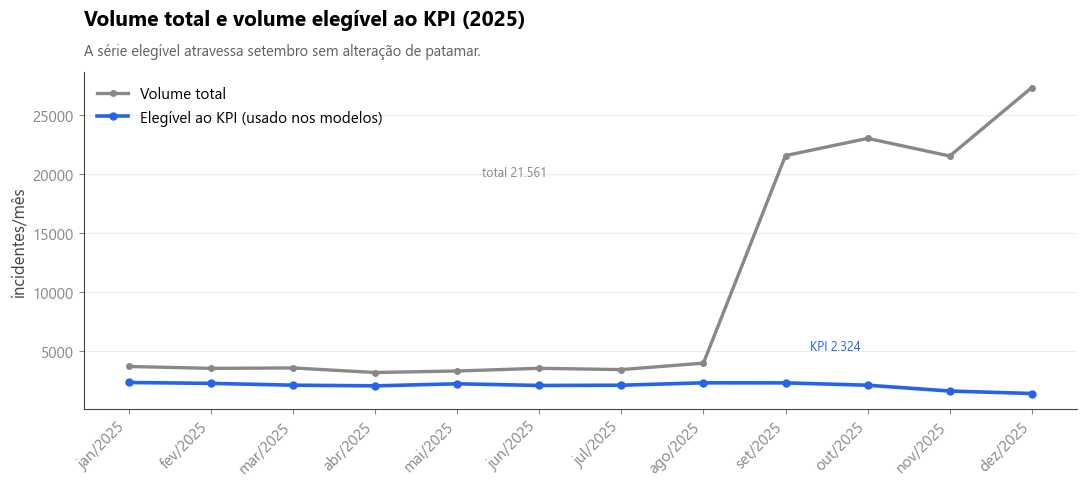

set/2025 -> total: 21561 | KPI: 2324
ago/2025 -> total: 3996 | KPI: 2330


In [16]:
vol_total = df_2025.groupby('mes').size().reindex(MESES_2025, fill_value=0)
vol_kpi = (df_kpi[df_kpi['mes'].isin(MESES_2025)]
           .groupby('mes').size().reindex(MESES_2025, fill_value=0))

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(MESES_2025))
ax.plot(x, vol_total.values, color=CRONOS_COLORS['mid_gray'], lw=2.4, marker='o', ms=4,
        label='Volume total')
ax.plot(x, vol_kpi.values, color=CRONOS_COLORS['accent'], lw=2.6, marker='o', ms=5,
        label='Elegível ao KPI (usado nos modelos)')
titulo_cronos(ax, 'Volume total e volume elegível ao KPI (2025)',
              'A série elegível atravessa setembro sem alteração de patamar.')
ax.set_ylabel('incidentes/mês')
ax.set_xticks(list(x))
ax.set_xticklabels([rotulo_mes(m) for m in MESES_2025], rotation=45, ha='right')
ax.legend(loc='upper left')
ax.annotate(f"total {int(vol_total['2025-09']):,}".replace(',', '.'), xy=(8, vol_total['2025-09']),
            xytext=(4.3, vol_total['2025-09'] * 0.92), fontsize=9, color=CRONOS_COLORS['mid_gray'])
ax.annotate(f"KPI {int(vol_kpi['2025-09']):,}".replace(',', '.'), xy=(8, vol_kpi['2025-09']),
            xytext=(8.3, vol_kpi['2025-09'] + 2800), fontsize=9, color=CRONOS_COLORS['accent'])
fig.tight_layout()
fig.savefig(FIGURES_DIR / '42b_total_vs_kpi.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print('set/2025 -> total:', int(vol_total['2025-09']), '| KPI:', int(vol_kpi['2025-09']))
print('ago/2025 -> total:', int(vol_total['2025-08']), '| KPI:', int(vol_kpi['2025-08']))

**A série elegível não registra a mudança:** 2.330 incidentes em agosto contra 2.324 em setembro. Os
17.565 registros adicionais têm origem automática e ficam fora do KPI.

**Consequência para a modelagem:** o alvo é a série elegível. Aplicado ao volume total, o modelo
interpretaria a mudança de instrumentação como tendência de crescimento. Os incidentes fora do
KPI permanecem na base para as demais análises.

### 4.3 Sazonalidade diária

Média de incidentes por dia da semana, sobre `df_kpi` restrito a 2025. A série é reindexada no
calendário completo do ano para que dias sem incidente contem como zero.

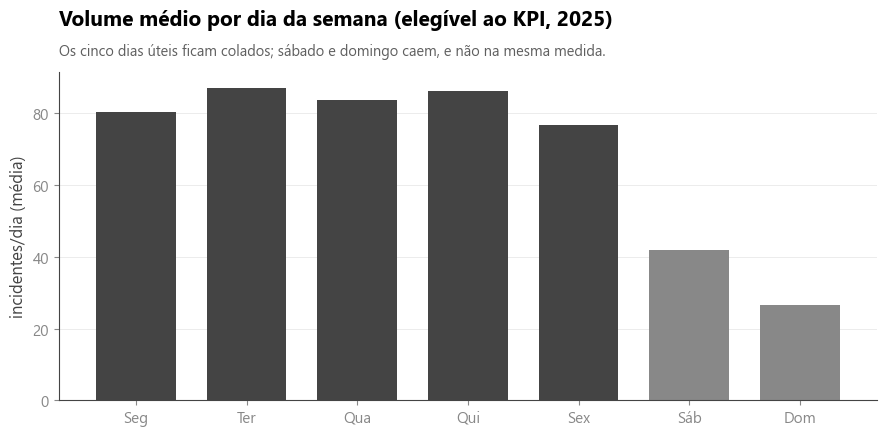

média de incidentes elegíveis por dia da semana (2025):
  Seg=80.3 | Ter=87.1 | Qua=83.7 | Qui=86.1 | Sex=76.6 | Sáb=41.8 | Dom=26.6
  faixa entre os dias úteis: 76.6 a 87.1


In [17]:
df_kpi_25 = df_kpi[df_kpi['Aberto'].dt.year == 2025]
dias_2025 = pd.date_range('2025-01-01', '2025-12-31', freq='D')
diario_kpi = df_kpi_25.groupby('data').size().reindex(dias_2025, fill_value=0)

dias_lbl = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
media_dow = diario_kpi.groupby(diario_kpi.index.dayofweek).mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
cores = [CRONOS_COLORS['mid_gray'] if k >= 5 else CRONOS_COLORS['dark_gray'] for k in range(7)]
ax.bar(dias_lbl, media_dow.values, color=cores, width=0.72)
titulo_cronos(ax, 'Volume médio por dia da semana (elegível ao KPI, 2025)',
              'Os cinco dias úteis ficam colados; sábado e domingo caem, e não na mesma medida.')
ax.set_ylabel('incidentes/dia (média)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '43a_dia_semana.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print('média de incidentes elegíveis por dia da semana (2025):')
print('  ' + ' | '.join(f'{r}={v:.1f}' for r, v in zip(dias_lbl, media_dow.values)))
print(f'  faixa entre os dias úteis: {media_dow.iloc[:5].min():.1f} a {media_dow.iloc[:5].max():.1f}')

Os cinco dias úteis ficam entre 76,6 e 87,1 incidentes por dia, amplitude insuficiente para
diferenciá-los. Sábado (41,8) e domingo (26,6) ficam abaixo, com diferença relevante entre si.

Segmentação seguinte: feriado nacional via `holidays.Brazil`, separando os que caem em dia útil
dos que caem em fim de semana, porque as duas condições se sobrepõem no calendário de 2025.

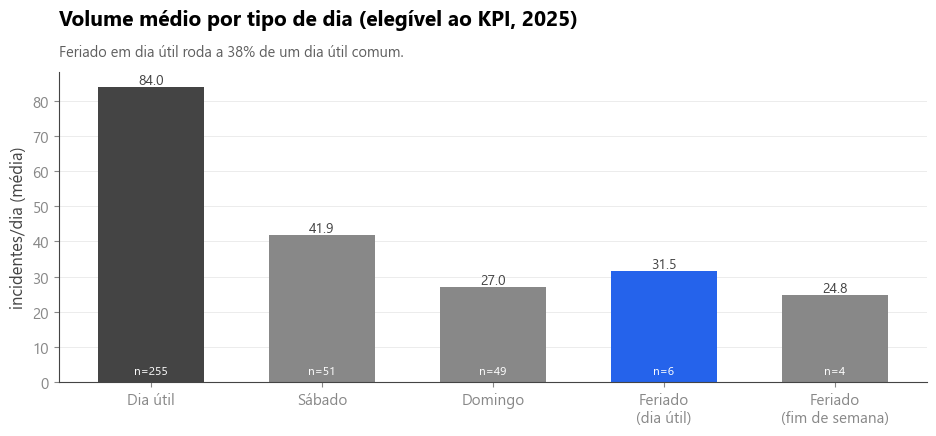

Dia útil                    84.0
Sábado                      41.9
Domingo                     27.0
Feriado em dia útil         31.5
Feriado no fim de semana    24.8

dias por categoria: {'Dia útil': 255, 'Sábado': 51, 'Domingo': 49, 'Feriado em dia útil': 6, 'Feriado no fim de semana': 4}
feriados de 2025 na série: 10 | em fim de semana: 4


In [18]:
feriados_br = holidays.Brazil(years=2025)
eh_feriado = pd.Series([d in feriados_br for d in diario_kpi.index], index=diario_kpi.index)
dow = diario_kpi.index.dayofweek
eh_fds = dow >= 5

# Feriado e fim de semana se sobrepõem em 2025. Agregar os dois em uma categoria só faria a
# média de feriado herdar o volume baixo do domingo, então cada combinação fica separada.
categoria = pd.Series(
    np.select(
        [eh_feriado & ~eh_fds, eh_feriado & eh_fds, dow == 5, dow == 6],
        ['Feriado em dia útil', 'Feriado no fim de semana', 'Sábado', 'Domingo'],
        default='Dia útil'),
    index=diario_kpi.index)

ordem_cat = ['Dia útil', 'Sábado', 'Domingo', 'Feriado em dia útil', 'Feriado no fim de semana']
media_cat = diario_kpi.groupby(categoria).mean().reindex(ordem_cat)
n_cat = categoria.value_counts().reindex(ordem_cat)
razao_feriado = media_cat['Feriado em dia útil'] / media_cat['Dia útil'] * 100

rotulos = ['Dia útil', 'Sábado', 'Domingo', 'Feriado\n(dia útil)', 'Feriado\n(fim de semana)']
cores_cat = [CRONOS_COLORS['dark_gray'], CRONOS_COLORS['mid_gray'], CRONOS_COLORS['mid_gray'],
             CRONOS_COLORS['accent'], CRONOS_COLORS['mid_gray']]

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(rotulos, media_cat.values, color=cores_cat, width=0.62)
titulo_cronos(ax, 'Volume médio por tipo de dia (elegível ao KPI, 2025)',
              f'Feriado em dia útil roda a {razao_feriado:.0f}% de um dia útil comum.')
ax.set_ylabel('incidentes/dia (média)')
for i, (v, n) in enumerate(zip(media_cat.values, n_cat.values)):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10, color='#444444')
    ax.text(i, 1.5, f'n={int(n)}', ha='center', va='bottom', fontsize=8.5, color='#FFFFFF')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '43b_tipo_dia.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(media_cat.round(1).to_string())
print('\ndias por categoria:', n_cat.to_dict())
print('feriados de 2025 na série:', int(eh_feriado.sum()),
      '| em fim de semana:', int((eh_feriado & eh_fds).sum()))

Feriado em dia útil roda a 31,5 incidentes/dia contra 84,0 de um dia útil comum, 37% do
movimento. Os 4 feriados que caem em sábado ou domingo ficam em 24,8, no nível do próprio fim de
semana. Agregar os 10 feriados em uma categoria única daria 28,8/dia, número que mistura os dois
regimes e subestima o efeito do feriado sobre a operação.

Sábado e domingo aparecem aqui com 41,9 e 27,0, contra 41,8 e 26,6 no gráfico por dia da
semana: aquele conta os 4 feriados dentro do próprio dia da semana e este os isola.

**A variável de calendário precisa combinar dia da semana e indicador de feriado.** Apenas com
dia da semana, 20 de novembro seria tratado como uma quinta-feira comum, com erro da ordem de 50
incidentes no dia.

### 4.4 Prioridade, status e origem

Distribuição dos três campos categóricos sobre a base completa, sem filtro de elegibilidade.

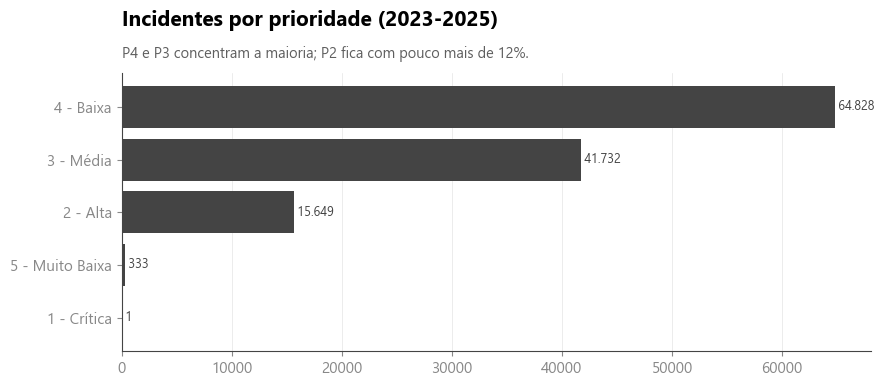

% por prioridade: {'4 - Baixa': 52.9, '3 - Média': 34.1, '2 - Alta': 12.8, '5 - Muito Baixa': 0.3, '1 - Crítica': 0.0}


In [19]:
prio = df['Prioridade'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
hbar_cronos(ax, prio)
titulo_cronos(ax, 'Incidentes por prioridade (2023-2025)',
              'P4 e P3 concentram a maioria; P2 fica com pouco mais de 12%.')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '44a_prioridade.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print('% por prioridade:', (prio / len(df) * 100).round(1).to_dict())

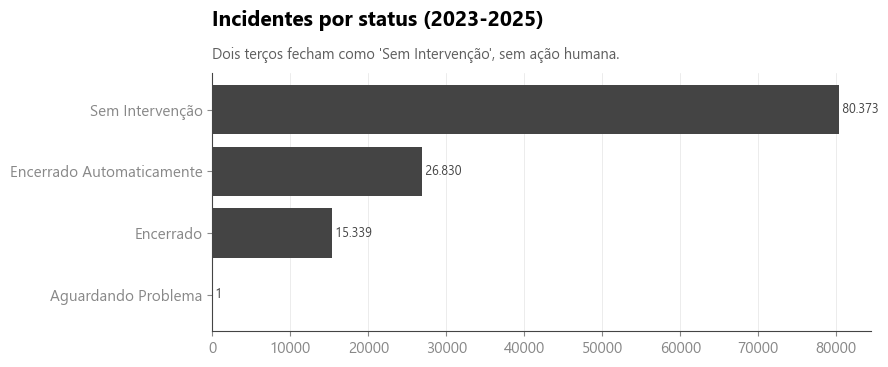

% por status: {'Sem Intervenção': 65.6, 'Encerrado Automaticamente': 21.9, 'Encerrado': 12.5, 'Aguardando Problema': 0.0}
% por origem: {'Monitoramento': 85.1, 'Manual': 14.9}


In [20]:
status = df['Status'].value_counts()

fig, ax = plt.subplots(figsize=(9, 3.8))
hbar_cronos(ax, status)
titulo_cronos(ax, 'Incidentes por status (2023-2025)',
              "Dois terços fecham como 'Sem Intervenção', sem ação humana.")
fig.tight_layout()
fig.savefig(FIGURES_DIR / '44b_status.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print('% por status:', (status / len(df) * 100).round(1).to_dict())
print('% por origem:', (df['Aberto por'].value_counts() / len(df) * 100).round(1).to_dict())

P4 (52,9%) e P3 (34,1%) somam 87,0% do volume. P2 responde por 12,8%; P1 e P5 são residuais.
65,6% dos incidentes encerram como `Sem Intervenção` e 85,1% têm origem em monitoramento.

O padrão da base completa reproduz, em escala de três anos, o mesmo perfil observado em setembro:
predominância de evento automático autorresolvido. **O filtro de elegibilidade isola P2 e P3
efetivamente tratados**, que são as prioridades com meta de KPI.

### 4.5 Concentração por produto e por equipe

Volume por `Produto` e por `Grupo designado`, critério de preenchimento de `Produto` e composição
do volume do Team14.

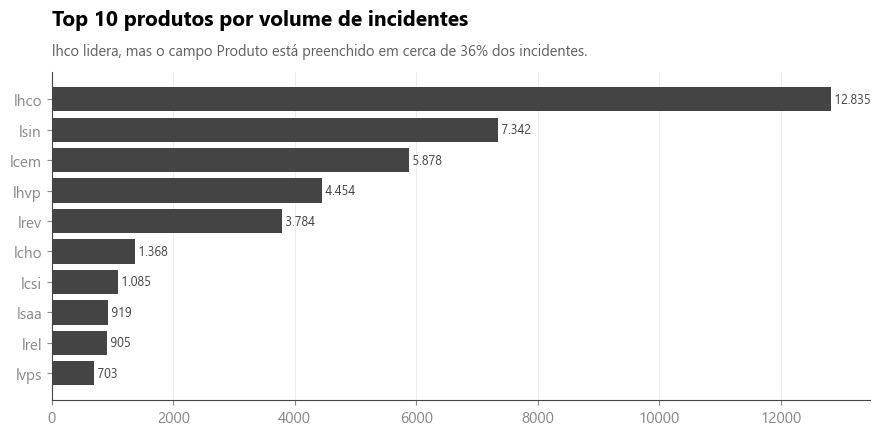

produto preenchido em 36.4% dos registros
produtos distintos: 51


In [21]:
fig, ax = plt.subplots(figsize=(9, 4.5))
hbar_cronos(ax, df['Produto'].value_counts().head(10))
titulo_cronos(ax, 'Top 10 produtos por volume de incidentes',
              'lhco lidera, mas o campo Produto está preenchido em cerca de 36% dos incidentes.')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '45a_produtos.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f"produto preenchido em {df['tem_produto'].mean() * 100:.1f}% dos registros")
print('produtos distintos:', df['Produto'].nunique())

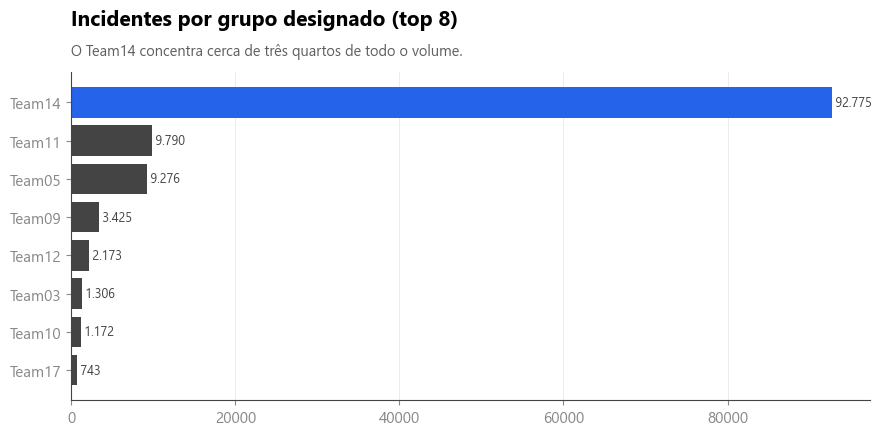

Team14: 92775 (75.7%)
2º e 3º: {'Team11': 9790, 'Team05': 9276}


In [22]:
grupos = df['Grupo designado'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
hbar_cronos(ax, grupos.head(8), destaque='Team14')
titulo_cronos(ax, 'Incidentes por grupo designado (top 8)',
              'O Team14 concentra cerca de três quartos de todo o volume.')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '45b_grupos.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print('Team14:', int(grupos.iloc[0]), f'({grupos.iloc[0] / len(df) * 100:.1f}%)')
print('2º e 3º:', grupos.iloc[1:3].to_dict())

A distribuição é concentrada. O Team14 responde por 75,7% dos incidentes; Team11 (8,0%) e Team05
(7,6%) vêm em seguida. Entre os 51 produtos distintos, lhco, lsin e lcem lideram, sobre os 36,4%
de registros com o campo preenchido.

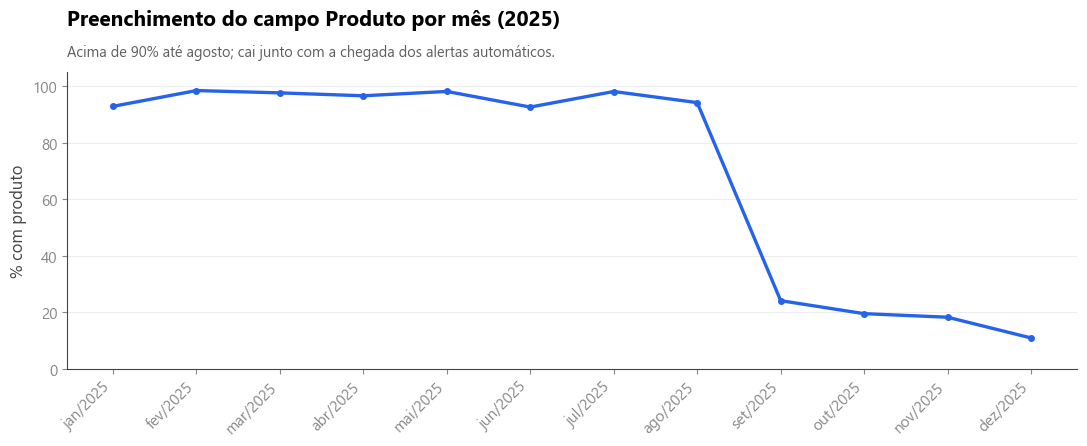

Aberto por : {'Manual': 99.4, 'Monitoramento': 25.4}
Status : {'Aguardando Problema': 100.0, 'Encerrado': 88.9, 'Encerrado Automaticamente': 98.3, 'Sem Intervenção': 5.7}
Entrou para KPI? : {'NAO': 19.7, 'SIM': 99.8}


In [23]:
fill_mensal = (df[df['mes'].isin(MESES_2025)]
               .groupby('mes')['tem_produto'].mean() * 100).reindex(MESES_2025)

fig, ax = plt.subplots(figsize=(11, 4.6))
x = range(len(MESES_2025))
ax.plot(x, fill_mensal.values, color=CRONOS_COLORS['accent'], lw=2.4, marker='o', ms=4)
titulo_cronos(ax, 'Preenchimento do campo Produto por mês (2025)',
              'Acima de 90% até agosto; cai junto com a chegada dos alertas automáticos.')
ax.set_ylabel('% com produto')
ax.set_ylim(0, 105)
ax.set_xticks(list(x))
ax.set_xticklabels([rotulo_mes(m) for m in MESES_2025], rotation=45, ha='right')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '45c_produto_fill.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

for col in ['Aberto por', 'Status', 'Entrou para KPI?']:
    print(col, ':', (df.groupby(col)['tem_produto'].mean() * 100).round(1).to_dict())

O preenchimento de `Produto` varia com o tipo de incidente: 99,4% na abertura manual, 98,3% em
`Encerrado Automaticamente`, 88,9% em `Encerrado` e 5,7% em `Sem Intervenção`. A queda a partir de
setembro corresponde à entrada dos alertas automáticos, que não recebem classificação de produto.

**No recorte elegível ao KPI o campo está preenchido em 99,8% dos registros.** A ausência de produto
em 63,6% da base completa não atinge o recorte usado pela solução, o que viabiliza o índice de
saúde por produto.

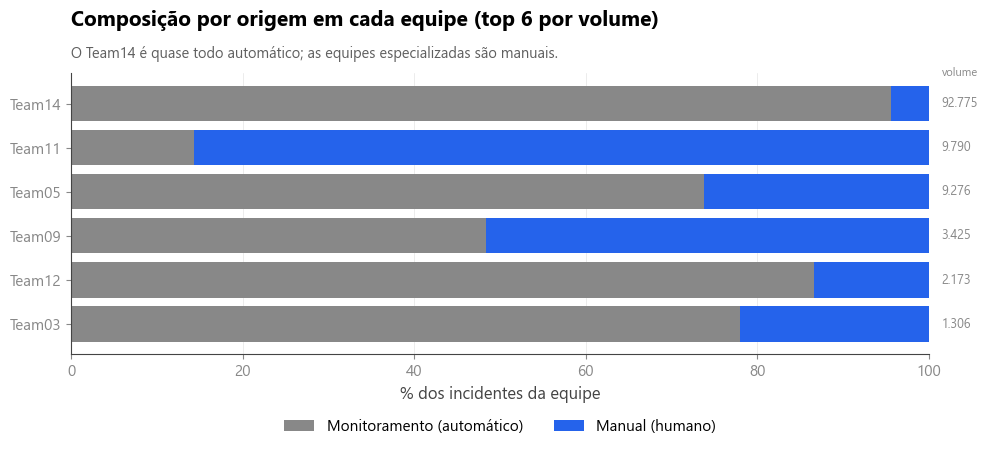

In [24]:
top_eq = df['Grupo designado'].value_counts().head(6).index.tolist()
comp = (df[df['Grupo designado'].isin(top_eq)]
        .groupby('Grupo designado')['Aberto por'].value_counts(normalize=True)
        .unstack().reindex(top_eq) * 100)
vol_eq = df['Grupo designado'].value_counts().reindex(top_eq)

ordem = top_eq[::-1]
comp = comp.reindex(ordem)
vol_eq = vol_eq.reindex(ordem)

fig, ax = plt.subplots(figsize=(10, 4.8))
y = range(len(ordem))
ax.barh(y, comp['Monitoramento'], color=CRONOS_COLORS['mid_gray'], label='Monitoramento (automático)')
ax.barh(y, comp['Manual'], left=comp['Monitoramento'], color=CRONOS_COLORS['accent'],
        label='Manual (humano)')
ax.set_yticks(list(y))
ax.set_yticklabels(ordem)
ax.set_xlim(0, 100)
ax.grid(axis='x')
ax.grid(axis='y', visible=False)
for i, t in enumerate(ordem):
    ax.text(101.5, i, f'{int(vol_eq[t]):,}'.replace(',', '.'), va='center', fontsize=9, color='#888888')
ax.text(101.5, len(ordem) - 0.3, 'volume', va='center', fontsize=8, color='#888888')
titulo_cronos(ax, 'Composição por origem em cada equipe (top 6 por volume)',
              'O Team14 é quase todo automático; as equipes especializadas são manuais.')
ax.set_xlabel('% dos incidentes da equipe')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '45d_origem_equipe.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [25]:
df_t14 = df[df['Grupo designado'] == 'Team14']
print(f'Team14: {len(df_t14):,} incidentes ({len(df_t14) / len(df) * 100:.1f}% do total)')
print(f"  origem automática (Monitoramento): {(df_t14['Aberto por'] == 'Monitoramento').mean() * 100:.1f}%")
print(f"  encerrados como 'Sem Intervenção': {(df_t14['Status'] == 'Sem Intervenção').mean() * 100:.1f}%")
print(f"  entram no KPI:                     {(df_t14['Entrou para KPI?'] == 'SIM').mean() * 100:.1f}%")
print(f"  violações de OLA:                  {int((df_t14['KPI Violado?'] == 'SIM').sum())}")

Team14: 92,775 incidentes (75.7% do total)
  origem automática (Monitoramento): 95.5%
  encerrados como 'Sem Intervenção': 81.5%
  entram no KPI:                     9.7%
  violações de OLA:                  10


Perfil do Team14: 95,5% de origem em monitoramento, 81,5% encerrados sem intervenção, 9,7% de
entrada no KPI e 10 violações de OLA em três anos. **A composição corresponde a um primeiro nível de
atendimento**, que absorve o alerta automático. As equipes especializadas apresentam volume menor,
com predominância de abertura manual e classificação preenchida.

O tamanho do Team14 mede alcance de automação; a carga de atendimento humano se concentra nas
equipes especializadas.

### 4.6 Violações de OLA no recorte elegível

Contagem e distribuição de `KPI Violado? == 'SIM'` sobre `df_kpi`, por prioridade, produto e
grupo designado. Esse campo é a variável-alvo do modelo de risco.

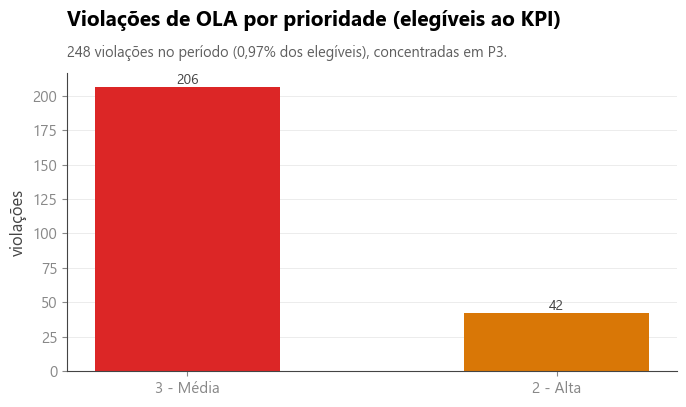

violações: 248 de 25,600 elegíveis (0.97%)
por prioridade: {'3 - Média': 206, '2 - Alta': 42}


In [26]:
df_violacoes = df_kpi[df_kpi['KPI Violado?'] == 'SIM']
taxa = len(df_violacoes) / len(df_kpi) * 100
por_prio = df_violacoes['Prioridade'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(por_prio.index, por_prio.values,
       color=[CRONOS_COLORS['danger'], CRONOS_COLORS['warning']][:len(por_prio)], width=0.5)
titulo_cronos(ax, 'Violações de OLA por prioridade (elegíveis ao KPI)',
              f"{len(df_violacoes)} violações no período "
              f"({f'{taxa:.2f}'.replace('.', ',')}% dos elegíveis), concentradas em P3.")
ax.set_ylabel('violações')
for i, v in enumerate(por_prio.values):
    ax.text(i, v, str(int(v)), ha='center', va='bottom', fontsize=10, color='#444444')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '46a_ola_prioridade.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f'violações: {len(df_violacoes)} de {len(df_kpi):,} elegíveis ({taxa:.2f}%)')
print('por prioridade:', por_prio.to_dict())

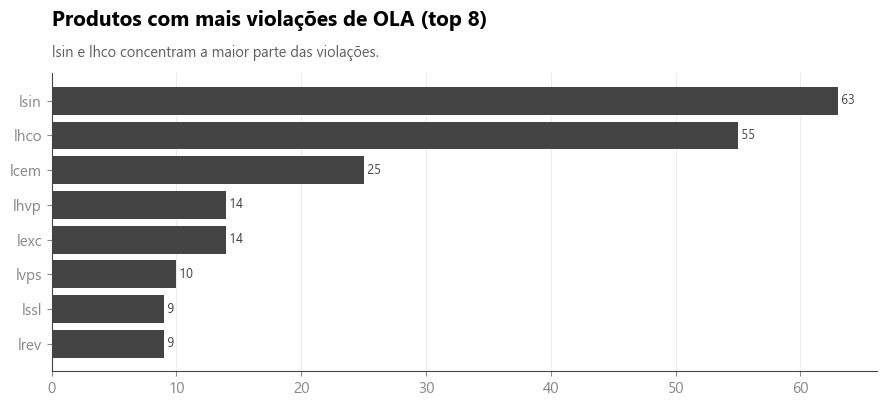

top grupos: {'Team11': 114, 'Team09': 56, 'Team07': 16}


In [27]:
fig, ax = plt.subplots(figsize=(9, 4.2))
hbar_cronos(ax, df_violacoes['Produto'].value_counts().head(8))
titulo_cronos(ax, 'Produtos com mais violações de OLA (top 8)',
              'lsin e lhco concentram a maior parte das violações.')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '46b_ola_produtos.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print('top grupos:', df_violacoes['Grupo designado'].value_counts().head(3).to_dict())

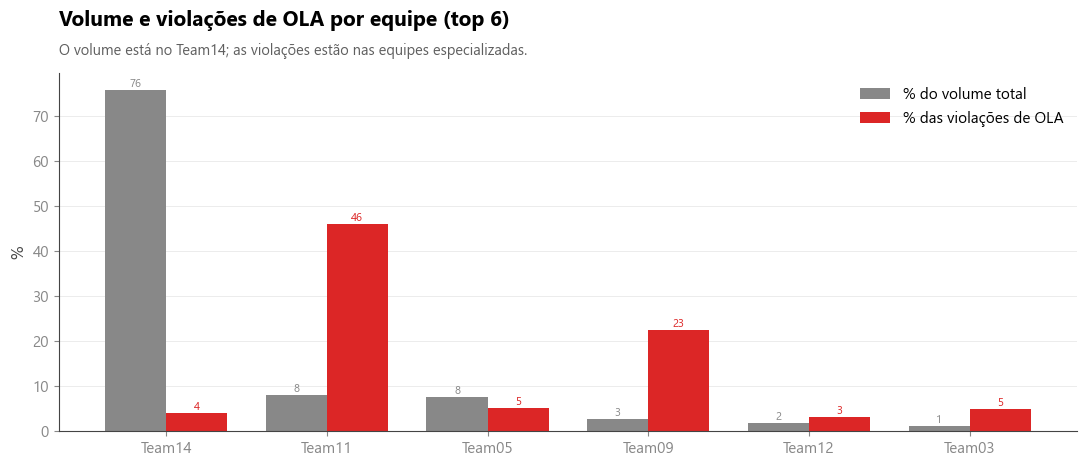

% do volume    : {'Team14': 75.7, 'Team11': 8.0, 'Team05': 7.6, 'Team09': 2.8, 'Team12': 1.8, 'Team03': 1.1}
% das violações: {'Team14': 4.0, 'Team11': 46.0, 'Team05': 5.2, 'Team09': 22.6, 'Team12': 3.2, 'Team03': 4.8}


In [28]:
vol_pct = (df['Grupo designado'].value_counts() / len(df) * 100).reindex(top_eq)
ola_pct = (df_violacoes['Grupo designado'].value_counts() / len(df_violacoes) * 100).reindex(top_eq).fillna(0)

fig, ax = plt.subplots(figsize=(11, 4.8))
x = np.arange(len(top_eq))
w = 0.38
ax.bar(x - w / 2, vol_pct.values, w, color=CRONOS_COLORS['mid_gray'], label='% do volume total')
ax.bar(x + w / 2, ola_pct.values, w, color=CRONOS_COLORS['danger'], label='% das violações de OLA')
titulo_cronos(ax, 'Volume e violações de OLA por equipe (top 6)',
              'O volume está no Team14; as violações estão nas equipes especializadas.')
ax.set_ylabel('%')
ax.set_xticks(list(x))
ax.set_xticklabels(top_eq)
ax.legend(loc='upper right')
for xi, (v, o) in enumerate(zip(vol_pct.values, ola_pct.values)):
    ax.text(xi - w / 2, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8, color='#888888')
    ax.text(xi + w / 2, o, f'{o:.0f}', ha='center', va='bottom', fontsize=8, color=CRONOS_COLORS['danger'])
fig.tight_layout()
fig.savefig(FIGURES_DIR / '45e_volume_vs_ola.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print('% do volume    :', vol_pct.round(1).to_dict())
print('% das violações:', ola_pct.round(1).to_dict())

**São 248 violações em 25.600 registros elegíveis, taxa de 0,97%.** P3 responde por 206 e P2 por 42.
Por produto, lsin e lhco lideram; por equipe, Team11 (114) e Team09 (56).

A distribuição por equipe é o inverso da distribuição de volume: o Team11 concentra 8,0% dos
incidentes e 46,0% das violações; o Team09, 2,8% e 22,6%. O Team14, com 75,7% do volume, responde
por 4,0% das violações.

O alvo é uma classe rara, com 0,97% de positivos. **A acurácia é inadequada como métrica de
avaliação:** um classificador constante em "não viola" atinge 99,03%. A avaliação usa precisão e
recall.

## 5. Conclusão

**O período aproveitável é 2025.** Os dois primeiros anos somam 732 incidentes, insuficientes para
treino e validação. O recorte elegível ao KPI, com 25.600 registros, é estável ao longo de 2025,
atravessa a mudança de setembro sem alteração de patamar, tem `Produto` preenchido em 99,8% dos
casos e separa P2 e P3, que têm metas próprias. É o alvo da previsão de volume, com variáveis de
calendário combinando dia da semana e indicador de feriado.

**A restrição está no risco de OLA:** 248 positivos em 25.600 registros configuram classe rara, o que
exige validação específica e métricas adequadas ao desbalanceamento.